### **1. Library Imports**

In [ ]:
import pandas as pd
import numpy as np

# Data Visualization
import plotly.express as px
import plotly.graph_objs as go
import plotly.subplots as sp
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import plotly.io as pio
from IPython.display import display
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
import seaborn as sns

# Diabetes dataset
from sklearn.datasets import load_diabetes

# For splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Metric for evaluation
from sklearn.metrics import mean_squared_error

# Statsmodels for Linear Regression
import statsmodels.api as sm

# Hiding warnings 
import warnings
warnings.filterwarnings("ignore")

### **2. Data Loading + Alignment**

In [2]:
X, y = load_diabetes(return_X_y = True)

In [5]:
X_df = pd.DataFrame(X, columns=[f'X{i+1}' for i in range(X.shape[1])])
X_df

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [6]:
y_df = pd.DataFrame(y, columns=['Target'])
y_df

,Target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


In [10]:
# inspect shapes
print(X_df.shape)
print(y_df.shape)

(442, 10)
(442, 1)


In [13]:
# inspect columns
print(X_df.columns.tolist())
print(y_df.columns.tolist())

['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10']
['Target']


In [14]:
# inspect dtypes
print(X_df.dtypes)
print(y_df.dtypes)

X1     float64
X2     float64
X3     float64
X4     float64
X5     float64
X6     float64
X7     float64
X8     float64
X9     float64
X10    float64
dtype: object
Target    float64
dtype: object


In [18]:
# verify index structure
print(X_df.index.equals(y_df.index))
print(X_df.index.is_unique)
print(y_df.index.is_unique)

True
True
True


In [19]:
# check row duplication
print(X_df.duplicated().sum())
print(y_df.duplicated().sum())

0
228


In [20]:
print(len(X_df))
print(len(y_df))

442
442


In [21]:
df = pd.concat([X_df, y_df], axis = 1)
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### **2. Data Validation**

In [27]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      442 non-null    float64
 1   X2      442 non-null    float64
 2   X3      442 non-null    float64
 3   X4      442 non-null    float64
 4   X5      442 non-null    float64
 5   X6      442 non-null    float64
 6   X7      442 non-null    float64
 7   X8      442 non-null    float64
 8   X9      442 non-null    float64
 9   X10     442 non-null    float64
 10  Target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None


In [37]:
print(df.describe())

                 X1            X2            X3            X4            X5  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 X6            X7            X8            X9           X10  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.268604e-17  1.130318e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.

In [ ]:
# null count summary
print(df.isnull().sum())

X1        0
X2        0
X3        0
X4        0
X5        0
X6        0
X7        0
X8        0
X9        0
X10       0
Target    0
dtype: int64


In [32]:
# constant column checks
const = [col for col in df.columns if df[col].nunique()==1]
print(const)

[]


In [33]:
# near constatn check
print(df.nunique())

X1         58
X2          2
X3        163
X4        100
X5        141
X6        302
X7         63
X8         66
X9        184
X10        56
Target    214
dtype: int64


In [ ]:
# target variable analysis
print(df.Target.describe())
print(df.Target.isnull().sum())
print(df.Target.nunique())
print(df.Target.min())
print(df.Target.max())

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: Target, dtype: float64
0
214
25.0
346.0


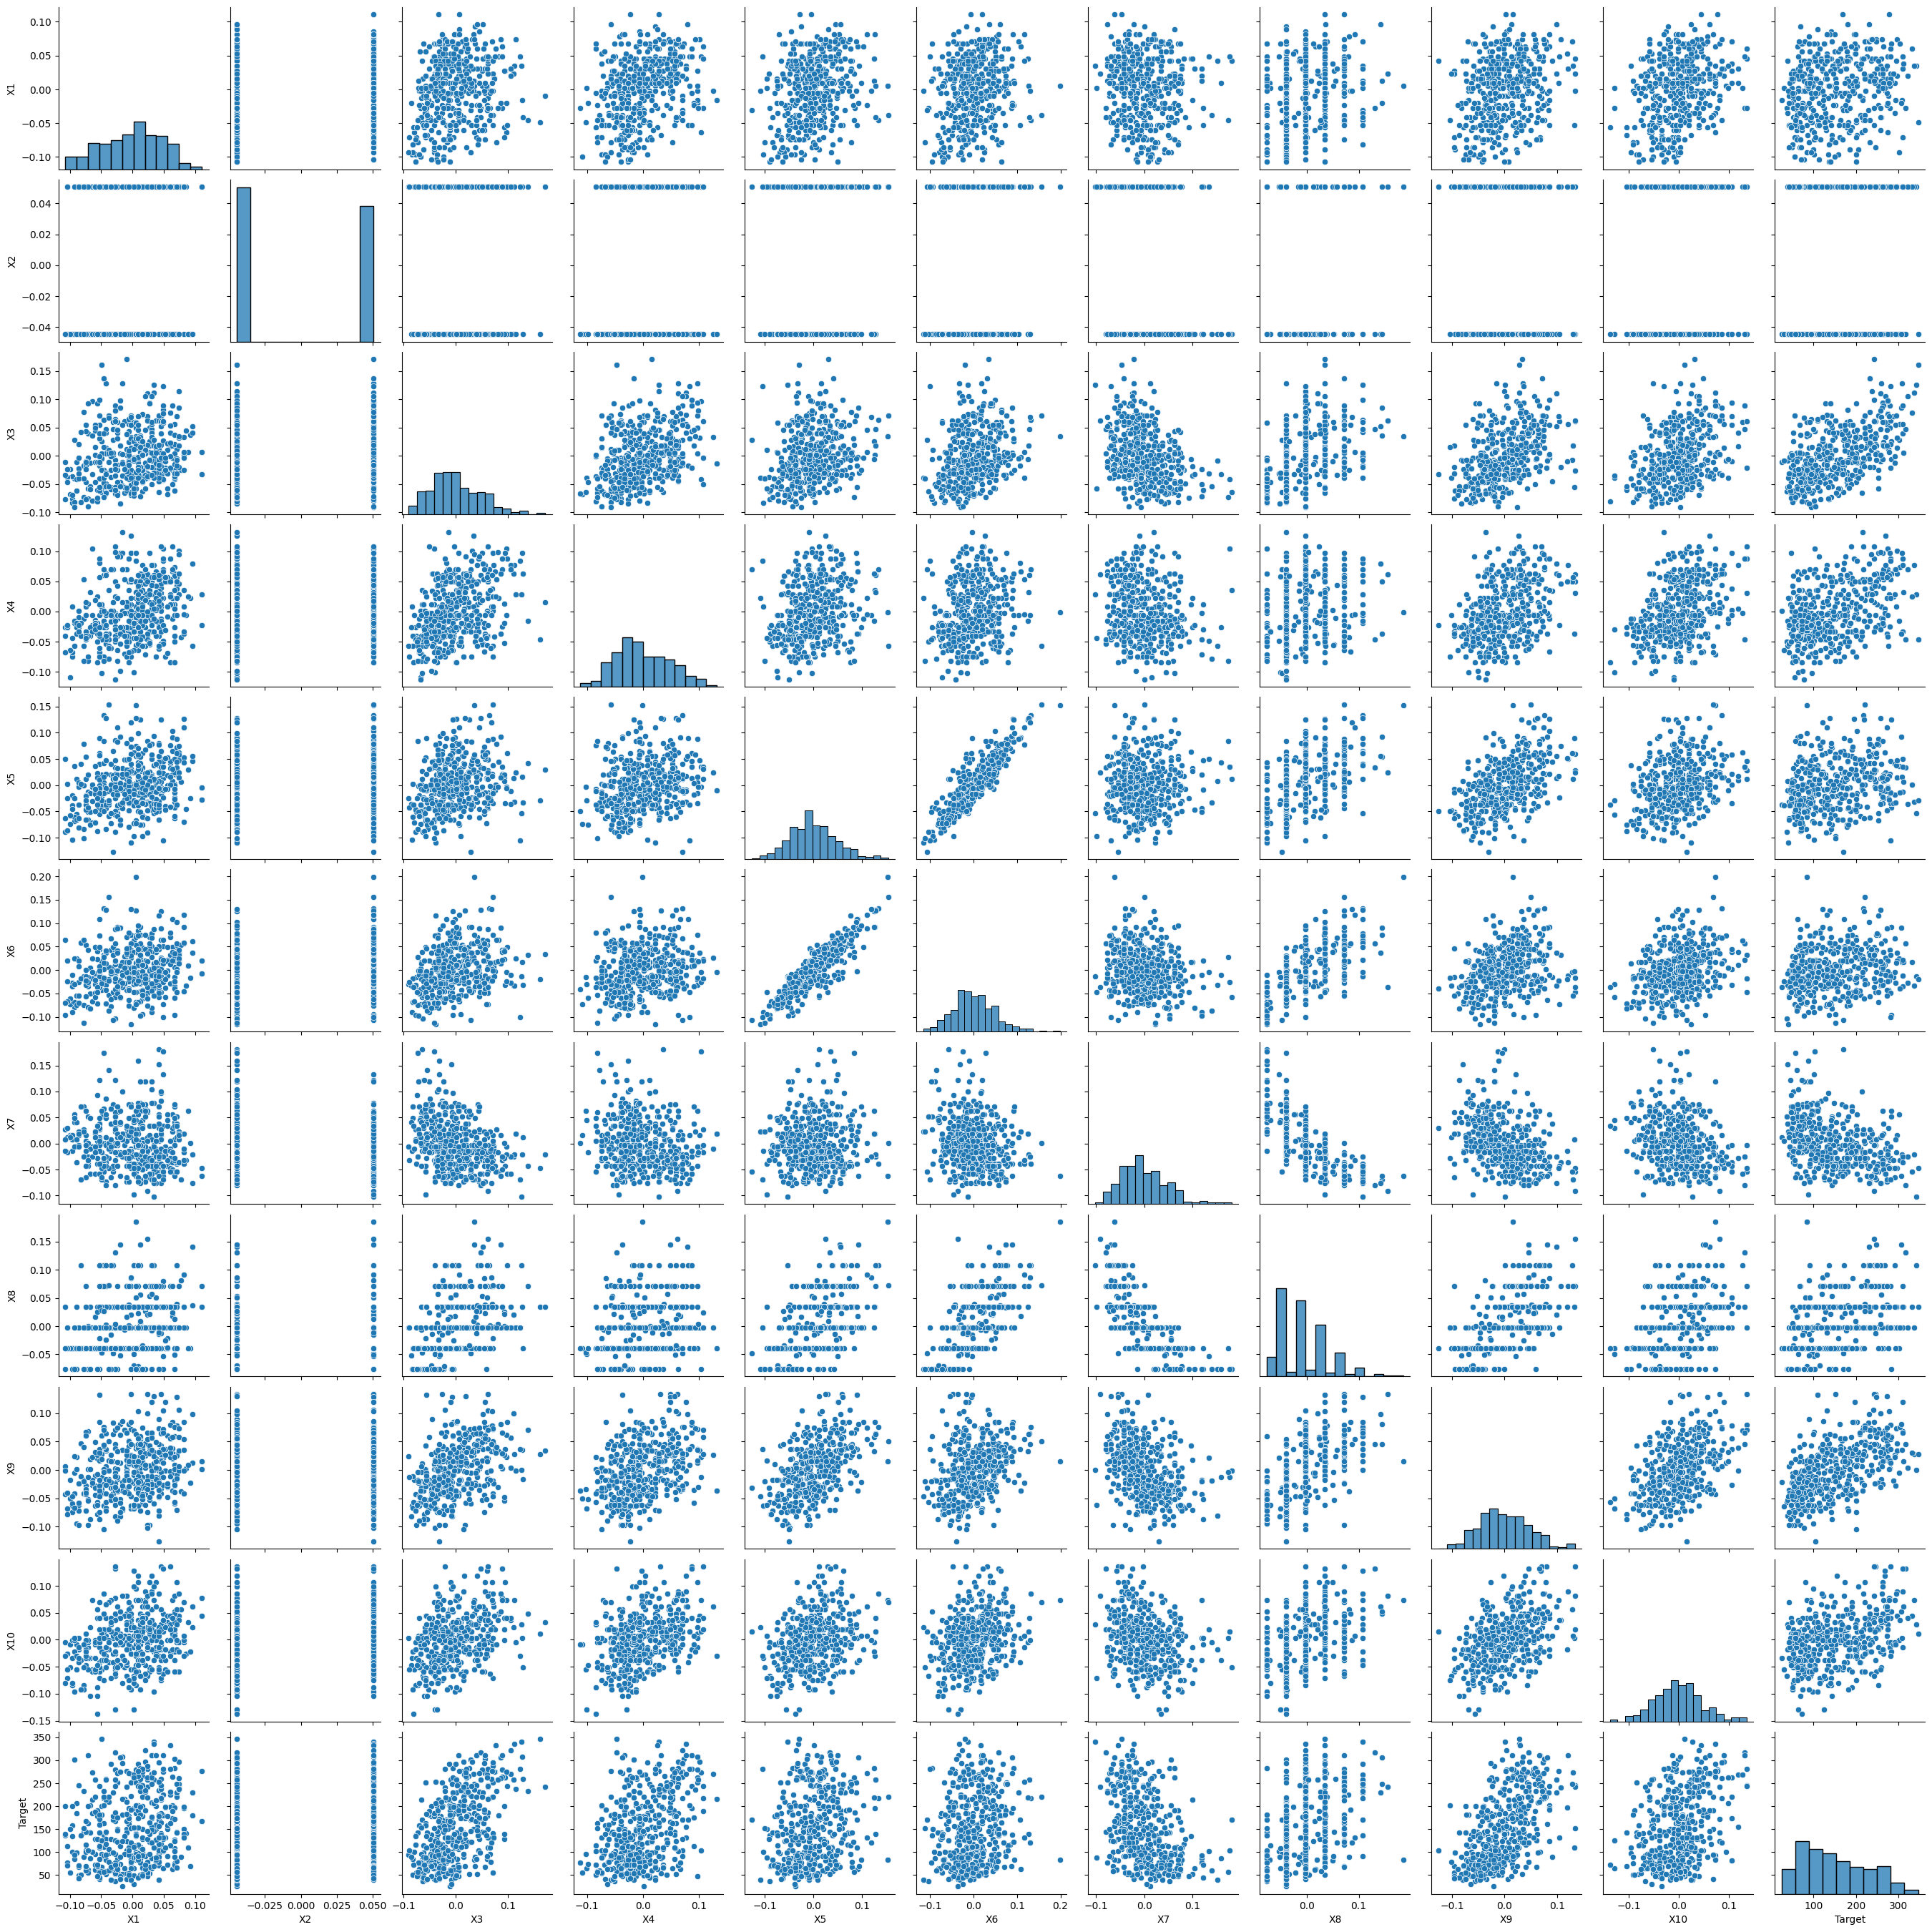

In [39]:
sns.pairplot(df)

<Axes: xlabel='X8', ylabel='Target'>

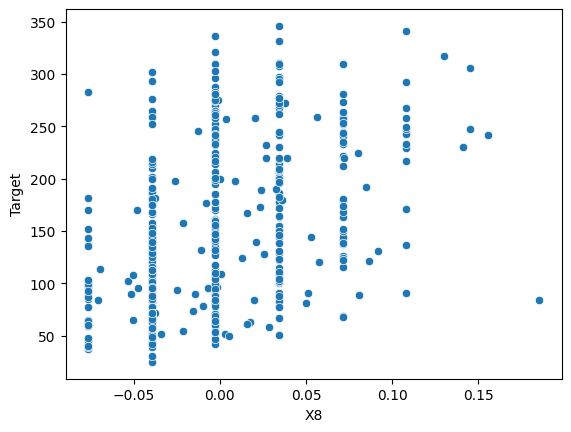

In [45]:
sns.scatterplot(x="X8", y="Target", data=df)

### **3. Train Test Split**

In [46]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=99)

In [49]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(331, 10)
(111, 10)
(331,)
(111,)


In [51]:
print(y_train.describe())
print(y_test.describe())

count    331.000000
mean     152.066465
std       77.884112
min       25.000000
25%       86.500000
50%      142.000000
75%      211.000000
max      346.000000
Name: Target, dtype: float64
count    111.000000
mean     152.333333
std       75.029974
min       37.000000
25%       89.000000
50%      137.000000
75%      211.000000
max      341.000000
Name: Target, dtype: float64


### **4. Preprocessing on Training Set**

### **5. Exploratory Data Analysis on Training Set**

### **6. Baseline Model**

### **7. Regression Diagnostics**

### 1. Linearity

### 2. Multicollinearity among features

In [10]:
corr = np.round(df.corr(), 2) # Computing correlation
target_corr = corr.loc[['Target'], :].drop(columns=['Target']) # Filtering for the Target variable

# Creating annotated heatmap
fig = ff.create_annotated_heatmap(z=target_corr.values,
                                  x=target_corr.columns.tolist(),
                                  y=['Target'],
                                  colorscale='Magenta')

# Updating layout
fig.update_layout(title={'text': '<b>Correlation Between Target and Independent Variables</b>',
                        'x': 0.05, 'xanchor': 'left'},
                  margin=dict(t=210, l=110),
                  yaxis=dict(showgrid=False),
                  xaxis=dict(showgrid=False),
                  plot_bgcolor='#F6F5F5',
                  paper_bgcolor='#F6F5F5',
                  height=300, width=950) 

# Configuring font size 
for i in range(len(fig.layout.annotations)):
    fig.layout.annotations[i].font.size = 12

fig.show()

In [11]:
# Measuring correlations
corr = np.round(df.corr(), 2)
corr = corr.drop('Target', axis=0).drop('Target', axis=1) # Removing target variable

# Filtering redundant values
mask = np.triu(np.ones_like(corr, dtype = bool))
c_mask = np.where(~mask, corr, 100)
c = []
for i in c_mask.tolist()[1:]:
    c.append([x for x in i if x != 100])

# Creating annotated heatmap
fig = ff.create_annotated_heatmap(z=c[::-1],
                                  x=corr.index.tolist()[:-1],
                                  y=corr.columns.tolist()[1:][::-1],
                                  colorscale = 'Magenta')

fig.update_layout(title = {'text': '<b>Correlation Among Independent Features</b>',
                           'x': 0.05, 'xanchor': 'left'},
                  margin = dict(t=210, l = 110),
                  yaxis = dict(autorange = 'reversed', showgrid = False),
                  xaxis = dict(showgrid = False),
                  plot_bgcolor = '#F6F5F5',
                  paper_bgcolor = '#F6F5F5',
                  height = 950, width = 950)
                     

fig.add_trace(go.Heatmap(z = c[::-1],
                         colorscale = 'Magenta',
                         showscale = True,
                         visible = False))
fig.data[1].visible = True
for i in range(len(fig.layout.annotations)):
    fig.layout.annotations[i].font.size = 12

fig.show()

In [13]:
fig = px.scatter(df, x='F5', y='F6',
                 opacity = 0.825,
                 template= 'seaborn')

fig.update_traces(marker={'size': 8,
                         'color': 'magenta'})

fig.update_layout(title= {'text': f'<b>Scatter Plot Between Feature 5 and Feature 6</b>',
                          'x': 0.05, 'xanchor': 'left', 'y': 0.98},
                  showlegend=True,
                  plot_bgcolor='#F6F5F5',
                  paper_bgcolor='#F6F5F5',
                  height=650, width=850)
                
fig.show()

## **Modeling**

In [14]:
X = df.drop('Target', axis = 1) # Selecting independent features
y = df.Target # Selecting target variable

In [16]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size = 0.2, shuffle = True, random_state = 42)

In [17]:
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

In [18]:
X_train

,const,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10
17,1.0,0.070769,0.050680,0.012117,0.056301,0.034206,0.049416,-0.039719,0.034309,0.027364,-0.001078
66,1.0,-0.009147,0.050680,-0.018062,-0.033213,-0.020832,0.012152,-0.072854,0.071210,0.000272,0.019633
137,1.0,0.005383,-0.044642,0.049840,0.097615,-0.015328,-0.016345,-0.006584,-0.002592,0.017036,-0.013504
245,1.0,-0.027310,-0.044642,-0.035307,-0.029770,-0.056607,-0.058620,0.030232,-0.039493,-0.049872,-0.129483
31,1.0,-0.023677,-0.044642,-0.065486,-0.081413,-0.038720,-0.053610,0.059685,-0.076395,-0.037129,-0.042499
...,...,...,...,...,...,...,...,...,...,...,...
106,1.0,-0.096328,-0.044642,-0.076264,-0.043542,-0.045599,-0.034821,0.008142,-0.039493,-0.059471,-0.083920
270,1.0,0.005383,0.050680,0.030440,0.083844,-0.037344,-0.047347,0.015505,-0.039493,0.008641,0.015491
348,1.0,0.030811,-0.044642,-0.020218,-0.005670,-0.004321,-0.029497,0.078093,-0.039493,-0.010903,-0.001078
435,1.0,-0.012780,-0.044642,-0.023451,-0.040099,-0.016704,0.004636,-0.017629,-0.002592,-0.038460,-0.038357


In [20]:
model = sm.OLS(y_train, X_train).fit()
print(model.summary(alpha=0.05))

                            OLS Regression Results                            
Dep. Variable:                 Target   R-squared:                       0.528
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     38.25
Date:                Wed, 13 Aug 2025   Prob (F-statistic):           5.41e-50
Time:                        11:42:54   Log-Likelihood:                -1906.1
No. Observations:                 353   AIC:                             3834.
Df Residuals:                     342   BIC:                             3877.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        151.3456      2.902     52.155      0.0

In [21]:
residuals = model.resid # Obtaining residuals

# Creating a distribution plot
fig = ff.create_distplot([residuals], ['Residuals'], bin_size=10)
fig.update_layout(title={'text': '<b>Distribution Plot of Residuals</b>',
                         'x': 0.05, 'xanchor': 'left'},
                  plot_bgcolor='#F6F5F5',
                  paper_bgcolor='#F6F5F5',
                  height=750, width=950,
                  showlegend=False)

fig.show()

In [22]:
y_pred = model.predict(X_test) # Running predictions
rmse = mean_squared_error(y_test, y_pred,squared = False) # Computing RMSE

print(f'\nRoot Mean Squared Error for Baseline Model: {rmse:.2f}')


Root Mean Squared Error for Baseline Model: 53.85


In [23]:
plot_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}) # Creating Dataframe containing actual and predicted values

fig = px.scatter(plot_df, x='Actual', y='Predicted', opacity=0.825, template='seaborn') # Creating scatterplot
fig.add_traces(px.scatter(plot_df, x='Actual', y='Predicted', trendline="ols").data[1]) # Obtaining the fit line

fig.update_traces(marker={'size': 8})

fig.update_layout(title={'text': f'<b>Scatter Plot Between Actual and Predicted Values <br> <sub>First Model</sub></b>',
                         'x': 0.05, 'xanchor': 'left', 'y': 0.968},
                  showlegend=True,
                  plot_bgcolor='#F6F5F5',
                  paper_bgcolor='#F6F5F5',
                  height=650, width=850)
                
fig.show()

In [25]:
# Selecting feature to remove
features_to_remove = ['F2',
                     'F6']

# Removing them
new_X_train = X_train.drop(features_to_remove, axis =1)
new_X_test = X_test.drop(features_to_remove, axis =1)

In [26]:
new_X_train # Visualizing new X dataframe


,const,F1,F3,F4,F5,F7,F8,F9,F10
17,1.0,0.070769,0.012117,0.056301,0.034206,-0.039719,0.034309,0.027364,-0.001078
66,1.0,-0.009147,-0.018062,-0.033213,-0.020832,-0.072854,0.071210,0.000272,0.019633
137,1.0,0.005383,0.049840,0.097615,-0.015328,-0.006584,-0.002592,0.017036,-0.013504
245,1.0,-0.027310,-0.035307,-0.029770,-0.056607,0.030232,-0.039493,-0.049872,-0.129483
31,1.0,-0.023677,-0.065486,-0.081413,-0.038720,0.059685,-0.076395,-0.037129,-0.042499
...,...,...,...,...,...,...,...,...,...
106,1.0,-0.096328,-0.076264,-0.043542,-0.045599,0.008142,-0.039493,-0.059471,-0.083920
270,1.0,0.005383,0.030440,0.083844,-0.037344,0.015505,-0.039493,0.008641,0.015491
348,1.0,0.030811,-0.020218,-0.005670,-0.004321,0.078093,-0.039493,-0.010903,-0.001078
435,1.0,-0.012780,-0.023451,-0.040099,-0.016704,-0.017629,-0.002592,-0.038460,-0.038357


In [27]:
# Fitting model
model = sm.OLS(y_train, new_X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Target   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.497
Method:                 Least Squares   F-statistic:                     44.40
Date:                Wed, 13 Aug 2025   Prob (F-statistic):           1.21e-48
Time:                        12:14:51   Log-Likelihood:                -1913.4
No. Observations:                 353   AIC:                             3845.
Df Residuals:                     344   BIC:                             3880.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        151.3480      2.954     51.243      0.0

### **Refined Model**